# Lesson 2: Chain-of-Thought and ReACT Prompting

## Demand‑Spike Detective, Part I: Chain-of-Thoughts

In this hands-on exercise, you will guide an LLM to explain an unexpected sales spike.

### Outline:
- Setup
- Understand sales data, promotional calendars, etc. 
- Craft a Simple CoT prompt
- Craft a More Developed CoT Prompt

## 1. Setup

Let's start by setting up the environment.

In [2]:
# Import necessary libraries
# No changes needed in this cell

import os

import pandas as pd
from IPython.display import Markdown, display
from lesson_2_lib import (
    # Helpers
    DeepSeekModels,
    display_responses,
    # Synthetic data
    get_competitor_pricing_data,
    get_completion,
    get_promotions_data,
    get_sales_data,
    get_weather_data,
)
from openai import OpenAI

MODEL = DeepSeekModels.DS_V4_FLASH


In [3]:
# If using the Vocareum API endpoint
# No changes needed in this cell
# TODO: Fill in the missing parts marked with **********

client = OpenAI(
    base_url="https://api.deepseek.com",
    # Uncomment one of the following
    # api_key="**********",  # <--- TODO: Fill in your Vocareum API key here
    api_key=os.environ.get(
        "DS_API_KEY"
    ),  # <-- Alternately, set as an environment variable (more secure)
)

# If using OpenAI's API endpoint
# client = OpenAI()


## 2. Understand sales data, promotional calendars, etc.

First, let's review the sample data provided. Working with AI Agents is still a data problem at its core, so the first steps are always to understand the business goals (explain the cause for the spike) and the underlying data.

In [5]:
# View the data
get_sales_data()[:3]

[{'date': datetime.date(2024, 1, 10),
  'product_id': 'P001',
  'product_name': 'Product 1',
  'quantity': 255,
  'revenue': 15547.35},
 {'date': datetime.date(2024, 1, 10),
  'product_id': 'P002',
  'product_name': 'Product 2',
  'quantity': 65,
  'revenue': 2297.1},
 {'date': datetime.date(2024, 1, 10),
  'product_id': 'P003',
  'product_name': 'Product 3',
  'quantity': 90,
  'revenue': 7301.7}]

In [8]:
# Load the simulated data
# No changes needed in this cell

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

sales_data = get_sales_data()
sales_df = pd.DataFrame(sales_data)

promotions_data = get_promotions_data()
promotions_df = pd.DataFrame(promotions_data)

weather_data = get_weather_data()
weather_df = pd.DataFrame(weather_data)

competitor_pricing_data = get_competitor_pricing_data()
competitor_pricing_df = pd.DataFrame(competitor_pricing_data)


In [9]:
# Show the sales data
# No changes needed in this cell

sales_df = sales_df.sort_values(by=["product_id", "date"]).reset_index(drop=True)
sales_df


,date,product_id,product_name,quantity,revenue
0,2024-01-10,P001,Product 1,255,15547.35
1,2024-01-11,P001,Product 1,235,14327.95
2,2024-01-12,P001,Product 1,310,18900.70
3,2024-01-13,P001,Product 1,302,18412.94
4,2024-01-14,P001,Product 1,305,18595.85
5,2024-01-15,P001,Product 1,301,18351.97
6,2024-01-16,P001,Product 1,226,13779.22
7,2024-01-10,P002,Product 2,65,2297.10
8,2024-01-11,P002,Product 2,86,3039.24
9,2024-01-12,P002,Product 2,80,2827.20


In [10]:
# Show the promotions data
# No changes needed in this cell

promotions_df

,promotion_id,name,discount,products,start_date,end_date
0,PROMO001,Weekend Special,10% off,[P002],2024-01-12,2024-01-14
1,PROMO002,Flash Sale,15% off,"[P001, P003, P005]",2024-01-15,2024-01-16


In [11]:
# Show the weather data
# No changes needed in this cell

weather_df.head()

,date,temperature,conditions
0,2024-01-10,"{'fahrenheit': 23.4, 'celsius': -4.8}","{'main': 'Clear', 'precipitation': 'None', 'precipitation_amount': 0, 'special_event': None}"
1,2024-01-11,"{'fahrenheit': 39.3, 'celsius': 4.1}","{'main': 'Clear', 'precipitation': 'None', 'precipitation_amount': 0, 'special_event': None}"
2,2024-01-12,"{'fahrenheit': 41.1, 'celsius': 5.1}","{'main': 'Heavy Rain', 'precipitation': 'Heavy Rain', 'precipitation_amount': 2.7, 'special_event': 'Flood Warning'}"
3,2024-01-13,"{'fahrenheit': 27.2, 'celsius': -2.6}","{'main': 'Clear', 'precipitation': 'None', 'precipitation_amount': 0, 'special_event': None}"
4,2024-01-14,"{'fahrenheit': 22.9, 'celsius': -5.1}","{'main': 'Clear', 'precipitation': 'None', 'precipitation_amount': 0, 'special_event': None}"


In [12]:
# Show the competitor pricing data
# No changes needed in this cell

competitor_pricing_df

,product,date,our_price,competitor_sales,competitor_a_price,competitor_b_price,competitor_c_price
0,Product 1,2024-01-10,60.97,{},56.88,62.23,51.80
1,Product 1,2024-01-11,60.97,{},59.65,72.47,72.50
2,Product 1,2024-01-12,60.97,"{'CompetitorB': {'original_price': 69.24, 'sale_price': 50.55, 'discount_percentage': 27}, 'CompetitorC': {'original_price': 49.92, 'sale_price': 39.44, 'discount_percentage': 21}}",65.40,50.55,39.44
3,Product 1,2024-01-13,60.97,{},72.13,57.54,51.10
4,Product 1,2024-01-14,60.97,{},72.36,70.04,61.04
5,Product 1,2024-01-15,60.97,{},68.52,59.63,73.03
6,Product 1,2024-01-16,60.97,"{'CompetitorA': {'original_price': 53.84, 'sale_price': 44.69, 'discount_percentage': 17}}",44.69,57.69,70.51
7,Product 2,2024-01-10,35.34,{},34.57,42.01,42.02
8,Product 2,2024-01-11,35.34,"{'CompetitorB': {'original_price': 40.13, 'sale_price': 29.29, 'discount_percentage': 27}, 'CompetitorC': {'original_price': 28.93, 'sale_price': 22.85, 'discount_percentage': 21}}",37.91,29.29,22.85
9,Product 2,2024-01-12,35.34,{},41.81,33.35,29.62


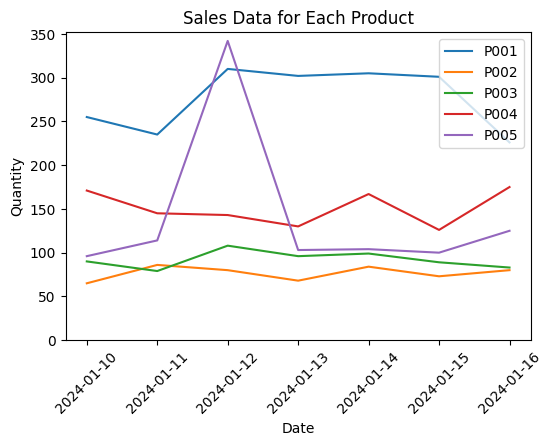

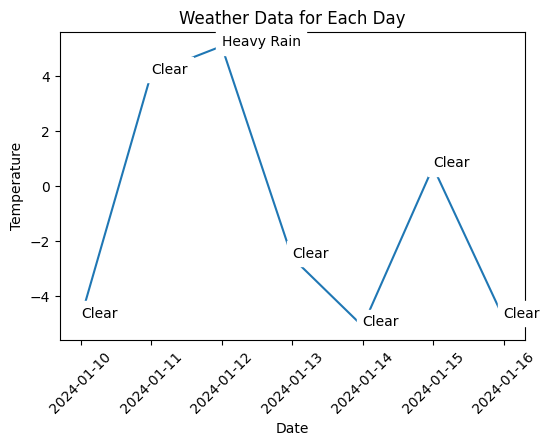

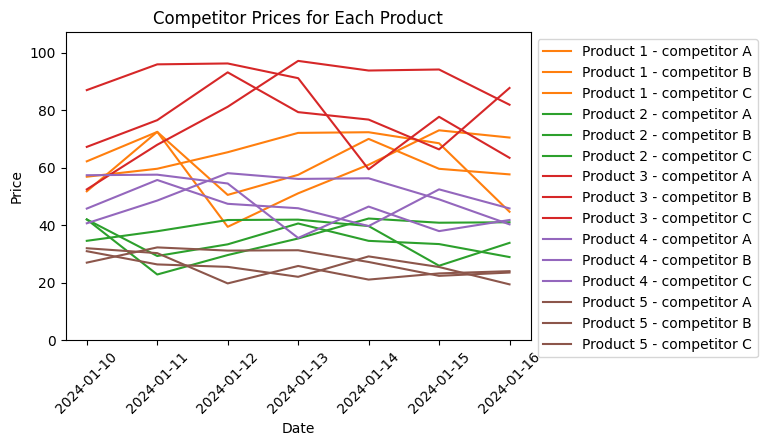

In [14]:
# Graph the sales data
# No changes needed in this cell

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
for product_id, product_data in sales_df.groupby("product_id"):
    product_data.sort_values(by="date", inplace=True)
    plt.plot(product_data["date"], product_data["quantity"], label=product_id)
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.title("Sales Data for Each Product")
plt.xticks(rotation=45)
plt.ylim(0, sales_df["quantity"].max() + 10)
plt.legend()
plt.show()

# Plot the weather data

weather_df["temperature_c"] = weather_df["temperature"].apply(lambda x: x["celsius"])


plt.figure(figsize=(6, 4))
plt.plot(weather_df["date"], weather_df["temperature_c"])

# For each day, add the value of "main" in text
for i, row in weather_df.iterrows():
    # Add a transparent background to the text
    plt.text(
        row["date"],
        row["temperature_c"],
        row["conditions"]["main"],
        backgroundcolor="white",
    )


plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Temperature")
plt.title("Weather Data for Each Day")
plt.show()

# Plot the competitor pricing data

plt.figure(figsize=(6, 4))
for product in competitor_pricing_df["product"].unique():
    for competitor in ["a", "b", "c"]:
        plt.plot(
            competitor_pricing_df[competitor_pricing_df["product"] == product]["date"],
            competitor_pricing_df[competitor_pricing_df["product"] == product][
                f"competitor_{competitor}_price"
            ],
            label=f"{product} - competitor {competitor.upper()}",
            color=f"C{product[-1]}",
        )
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Price")
plt.ylim(0, competitor_pricing_df.filter(like="price").max().max() + 10)
plt.title("Competitor Prices for Each Product")
# Put the legend outside the plot
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

### Reflect on the sales data

`TODO: Insert your reflection here`

Reflection:

* Sales spike for Product 5 on January 12th
* The "Weekend Special" promotion which started on January 12th, but that was for Product 2. Still, it may have had an indirect effect on Product 5.
* Weather was fluctuating between below freezing and above freezing. On the 12th in particular, there was heavy rain.
* As for Competitor pricing, we see that Product 5's price for one competitor dropped on January 12th, which may have led to more overall consumer interest in that product or may have coincided with an ad campaign.

In practice, a human would look at all these factors and more to determine the cause of the sales spike by digging deeper.

Let's see if we can get this far with a CoT prompt, which should at least find the sales spike and provide some reasons similar to what we've observed as human beings.

## 3. Craft a simple CoT prompt

Let's start with a simple CoT prompt. We won't tell the model to which steps to follow. We also won't use any tools in this example.

<div style="color: red">Note: Many modern LLMs may not need an explicit "think in steps" phrase in order to think in steps before providing an answer, as this behavior can be included in training process. Consider running your prompts with and without asking for CoT explicitly. In fact, multiple runs may yield different results, so it's worth simply re-running the same prompts more than once.</div>


In [15]:
# TODO: Fill in the part marked with ********** with a phrase such as "Think step by step."
# Feel free to try variations!

system_prompt_explicit_cot = """
你是一名一丝不苟的零售需求分析师。
你的任务是分析所提供的销售数据和促销安排，找出并解释特定 SKU 出现的显著销售激增。

请一步一步地思考。
"""

system_prompt_no_explicit_cot = """
你是一名一丝不苟的零售需求分析师。
你的任务是分析所提供的销售数据和促销安排，找出并解释特定 SKU 出现的显著销售激增。
"""

user_prompt_analyze = f"""
分析下面提供的数据，并对观察到的任何销售激增的原因提出假设。

销售数据：
{sales_data}

促销日历：
{promotions_data}

天气数据：
{weather_data}

竞争对手定价数据：
{competitor_pricing_data}
"""

print(f"Sending prompt to {MODEL} model...")
explicit_cot_response_1 = get_completion(
    system_prompt=system_prompt_explicit_cot, user_prompt=user_prompt_analyze,
    model=MODEL,
    client=client
)
no_explicit_cot_response_2 = get_completion(
    system_prompt=system_prompt_no_explicit_cot, user_prompt=user_prompt_analyze,
    model=MODEL,
    client=client
)
print("Response received!\n")

# We compare the explicit CoT and non-ex
display_responses(
    {
        "system_prompt": system_prompt_explicit_cot,
        "user_prompt": user_prompt_analyze,
        "response": explicit_cot_response_1,
    },
    {
        "system_prompt": system_prompt_no_explicit_cot,
        "user_prompt": user_prompt_analyze,
        "response": no_explicit_cot_response_2,
    },
)


Sending prompt to deepseek-v4-flash model...
Response received!



<table><tr><th>System Prompt:<br />
你是一名一丝不苟的零售需求分析师。
你的任务是分析所提供的销售数据和促销安排，找出并解释特定 SKU 出现的显著销售激增。

请一步一步地思考。
<br /><br />User Prompt:<br />
分析下面提供的数据，并对观察到的任何销售激增的原因提出假设。

销售数据：
[{'date': datetime.date(2024, 1, 10), 'product_id': 'P001', 'product_name': 'Product 1', 'quantity': 255, 'revenue': 15547.35}, {'date': datetime.date(2024, 1, 10), 'product_id': 'P002', 'product_name': 'Product 2', 'quantity': 65, 'revenue': 2297.1}, {'date': datetime.date(2024, 1, 10), 'product_id': 'P003', 'product_name': 'Product 3', 'quantity': 90, 'revenue': 7301.7}, {'date': datetime.date(2024, 1, 10), 'product_id': 'P004', 'product_name': 'Product 4... [truncated]</th><th>System Prompt:<br />
你是一名一丝不苟的零售需求分析师。
你的任务是分析所提供的销售数据和促销安排，找出并解释特定 SKU 出现的显著销售激增。
<br /><br />User Prompt:<br />
分析下面提供的数据，并对观察到的任何销售激增的原因提出假设。

销售数据：
[{'date': datetime.date(2024, 1, 10), 'product_id': 'P001', 'product_name': 'Product 1', 'quantity': 255, 'revenue': 15547.35}, {'date': datetime.date(2024, 1, 10), 'product_id': 'P002', 'product_name': 'Product 2', 'quantity': 65, 'revenue': 2297.1}, {'date': datetime.date(2024, 1, 10), 'product_id': 'P003', 'product_name': 'Product 3', 'quantity': 90, 'revenue': 7301.7}, {'date': datetime.date(2024, 1, 10), 'product_id': 'P004', 'product_name': 'Product 4... [truncated]</th></tr><tr><td>Response:<br />## 分析结论

从销量看，最明显的**异常激增**是：

- **2024-01-12，Product 5（P005）单日销量 342 件**
  - 前一天 1/11 为 114 件，环比增长 **+200%**
  - 剔除 1/12 后，P005 其余 6 天日均销量为 **107 件**
  - 1/12 销量是日均水平的 **约 3.2 倍**
  - 1/13 迅速回落到 **103 件**，说明这不是持续趋势，而是“尖峰式”激增

当天全店总销量也从 1/11 的 659 升至 983，P005 贡献了其中大部分增量。

### 同一天相关 SKU 的次要抬升

1/12 当天，部分 SKU 也有温和上升：

- P001：1/10-1/11 日均 245 件 → 1/12 为 310 件，上升约 **27%**
- P003：1/10-1/11 日均 84.5 件 → 1/12 为 108 件，上升约 **28%**

但这些没有 P005 那样极端。P001 之后几日仍在 300 件上下，可能有周末或后续促销叠加。

---

## 主要原因假设：天气驱动

最合理的假设是：**1/12 的大雨及洪水警告触发了 P005 的短期需求激增。**

关键证据：

1. 天气数据显示 1/12 为 **Heavy Rain / Flood Warning**，降水量 2.7；
2. P005 的激增恰好只出现在 1/12；
3. 1/13 天气转晴，P005 销量立刻回落到 103 件；
4. 如果 P005 是雨具、防水用品或与降雨/洪水相关的应急 SKU，这类需求会非常即时且集中在降雨当天；
5. P001、P003 同一天同步上升，也可能是在同一天气事件下产生的应急采购或组合购买。

因此，若 P005 属于“天气敏感型商品”，则这次激增大概率由 1/12 的强降水/洪水警告驱动。

---

## 排除促销与竞品降价解释

- P005 的自有促销 **Flash Sale** 开始于 **1/15**，而不是 1/12；
- 在 1/15-1/16 促销期间，P005 销量分别只有 100 件和 125 件，并没有出现类似 1/12 的暴增；
- P005 的竞品在 1/12 和 1/14 都有打折，但 1/14 天气晴朗时 P005 销量为 104 件，说明竞品促销本身不足以解释 1/12 的尖峰；
- 1/12 当天竞品 A 的 P005 价格甚至低于我方价格，若纯粹是价格冲击，不应导致我方销量增长如此明显。

所以，**自有促销和竞品价格都不是 1/12 激增的主因**。

---

## 建议

1. 核对 P005 的商品品类，确认它是否为雨具、防水用品或应急类商品；
2. 检查订单级数据，排除少数大客户/批发订单误计入 P005；
3. 如果 P005 确实为天气敏感型商品，建议在需求预测中加入天气预警变量，例如“Heavy Rain + Flood Warning”触发补货提醒或安全库存上调。</td><td>Response:<br />## 分析结论

先看各 SKU 的日销量：

| SKU | 1/10 | 1/11 | 1/12 | 1/13 | 1/14 | 1/15 | 1/16 |
|---|---:|---:|---:|---:|---:|---:|---:|
| P001 | 255 | 235 | **310** | 302 | 305 | 301 | 226 |
| P002 | 65 | 86 | 80 | 68 | 84 | 73 | 80 |
| P003 | 90 | 79 | **108** | 96 | 99 | 89 | 83 |
| P004 | 171 | 145 | 143 | 130 | 167 | 126 | 175 |
| P005 | 96 | 114 | **342** | 103 | 104 | 100 | 125 |
| 日合计 | 677 | 659 | **983** | 699 | 759 | 689 | 689 |

其中最显著的单一 SKU 日度尖峰是：

**P005 在 2024-01-12 销量 342 件。**

把它之外的 6 天均值作为“正常水平”计算：

- P005 正常日均销量约为 107 件；
- 1/12 的 342 件是正常水平的约 3.2 倍；
- 1/13 起迅速回落到 100～125 件，呈现典型的“尖峰后回落”。

同时，1/12 当日总销量 983 件也为全周最高。若去掉 1/12，其它日期日均销量约为 695 件，而 P005 在 1/12 比其正常水平多卖约 235 件，相当于当日总量增量的主要部分。

---

## 最可能原因假设

### P005 的激增大概率与天气事件相关：1/12 强降雨 / 洪水预警

关键时间线：

- 1/12 是数据内唯一出现 **Heavy Rain 强降雨**、降水量 2.7、并伴随 **Flood Warning 洪水预警** 的日期；
- P005 恰好在 1/12 出现全周最大销量；
- 1/13 起天气转晴，P005 销量立即回到 100 件左右。

因此，合理假设是：

> **P005 属于雨具、防水用品或应急类商品，1/12 的强降雨和洪水预警触发了临时性、集中性的购买需求。**

这与日常零售中“暴雨前/暴雨当天雨伞、雨靴、防水装备、应急用品销量骤增”的行为模式一致。

### 促销不能解释这次激增

促销日历显示：

- P002 在 1/12-1/14 有 Weekend Special，但 P002 销量并没有明显上升；
- P005 虽然出现在 1/15-1/16 的 Flash Sale 中，但激增发生在 1/12，早于该促销；
- 从 revenue / quantity 折算，P005 在 1/12 以及整个窗口内的单价都约为 26.95，没有出现 15% off 的价格变化。

所以 P005 的 1/12 激增不是由自有促销活动解释的。

---

## 其它相对温和的异常

P001 和 P003 在 1/12 也有温和上升：

- P001：1/10-1/11 均量为 245 件，1/12 为 310 件，1/12-1/15 维持在 300 件左右，随后 1/16 回落到 226 件；
- P003：1/10-1/11 均量为 84.5 件，1/12 为 108 件。

这些上升幅度远小于 P005，可能是同一天恶劣天气带来的“关联购物”或“应急备货”效应，也可能叠加了周末/假日因素；但仅凭现有数据，P001/P003 的波动更偏向温和抬升，而非显著激增。

---

## 待确认事项

该假设若要进一步验证，需要补充：

1. P005 的商品品类或商品属性；若它确实是雨具、防水用品、防洪应急品，则天气假设非常稳固；
2. 1/12 是否有大额批零订单或集中订单，因为 342 件的日销量明显偏离均值；
3. 渠道与门店数据，观察激增是否集中在特定受降雨/洪水影响区域；
4. 促销实际执行数据，确认 Flash Sale 是否真的以 15% 折扣结算，因为现有销售数据中未看到促销价生效痕迹。</td></tr></table>

### Observation

- What were the differences between including CoT and not including CoT explicitly in the prompt?

## 4. Craft a More Developed CoT Prompt

Let's add more to our CoT prompt. Let's ask the model to follow a specific set of steps in an **instructions section**. This may help us not only get final answers that align with our needs, but it will also help us constrain the output to a more specific format.

Finally, we'd like to the model to identify the single largest spike and hypothesize its causes, using the following output format:

````

STRUCTURED ANALYSIS:
[Structured Analysis]

LARGEST SPIKE:
```json
{
    "date": "YYYY-MM-DD",
    "amount_before_increase": "X.XX",
    "amount_after_increase": "X.XX",
    "percentage_increase": "X.XX%",
    "causes": [
        "Cause 1",
        "Cause 2",
        "Cause 3"
    ]
}
```

````

In [21]:
# Let's add some more components to our CoT Prompt
# TODO: Replace parts marked with a **********

system_prompt_cot = """
你是一名一丝不苟的零售需求分析师。
你的任务是分析所提供的销售数据和促销安排，找出并解释特定 SKU 出现的显著销售激增。

请分步骤进行思考。
"""

user_prompt_analyze = f"""
## 说明（INSTRUCTIONS）：

分析下面提供的数据，并对观察到的任何销售激增的原因提出假设。

步骤：
* 找出每个产品发生的所有销售激增
* 针对每个产品，说明以下信息：
    * 销售激增发生的日期
    * 销售激增的销量增幅及百分比增幅
    * 依据所提供的数据推断销售激增的可能原因：
        * 销售数据
        * 促销安排
        * 天气情况
        * 竞争对手定价数据
* 先给出你的分析
* 最后按百分比增幅找出最大的一次销售激增，并简要解释其原因。

--

## 输出格式（OUTPUT FORMAT）：

结构化分析：
[结构化分析内容]

最大销售激增：
```json
{{
    "date": "YYYY-MM-DD",
    "amount_before_increase": "X.XX",
    "amount_after_increase": "X.XX",
    "percentage_increase": "X.XX%",
    "causes": [
        "原因 1",
        "原因 2",
        "原因 3"
    ]
}}
```

---

## 背景数据（CONTEXT）：

销售数据：
{sales_data}

促销日历：
{promotions_data}

天气数据：
{weather_data}

竞争对手定价数据：
{competitor_pricing_data}
"""

print(f"Sending prompt to {MODEL} model...")
cot_response = get_completion(system_prompt=system_prompt_cot, user_prompt=user_prompt_analyze,
                              model=MODEL, client=client)
print("Response received!\n")


def parse_analysis_and_largest_spike(response):
    import json

    if "```json" not in response:
        print()
        print(response)
        raise RuntimeError(
            " ❌ No LARGEST SPIKE found in response. Looking for: \n\n```json"
        )

    analysis = response.split("```json")[0].strip()
    json_str = response.split("```json")[1].split("```")[0].strip()
    return analysis, json.loads(json_str)


analysis, largest_spike = parse_analysis_and_largest_spike(cot_response)

display(Markdown(analysis))

Sending prompt to OpenAIModels.GPT_41_NANO model...
Response received!



**STRUCTURED ANALYSIS**

---

### Product 1 (P001)
- **Sales Data:**
  - Jan 10: 255 units
  - Jan 11: 235 units
  - Jan 12: 310 units (peak)
  - Jan 13: 302 units
  - Jan 14: 305 units
  - Jan 15: 301 units
  - Jan 16: 226 units 
  
- **Observation:** The largest sales spike occurs on **2024-01-12** with 310 units, up from 235 units on Jan 11 (~31.9% increase).

- **Promotion Schedule:** No active promotion on Jan 12.

- **Weather:** Light conditions (clear, mild temperatures).

- **Competitor Pricing:** On Jan 12, our price was $60.97. Competitors' prices varied, with one competitor (Competitor B) offering a sale at $50.55 (27% discount). Our price was higher than some competitors but not the lowest.

- **Possible causes:**
  - The spike could be due to natural weekly demand increase or inventory replenishment.
  - Slightly favorable competitor pricing on Jan 12 (e.g., B’s sale) might have driven some customers, but our consistent pricing suggests internal factors are more relevant.
  - No promotion or weather anomalies correlate directly.

---

### Product 2 (P002)
- **Sales Data:**
  - Jan 10: 65
  - Jan 11: 86 (increase)
  - Jan 12: 80
  - Jan 13: 68
  - Jan 14: 84
  - Jan 15: 73
  - Jan 16: 80

- **Observation:** The highest sales occur on Jan 11 with 86 units, a 32.3% increase from Jan 10.

- **Promotion Schedule:** No active promotion.

- **Weather:** Temperatures mild, no extreme weather.

- **Competitor Pricing:**
  - Jan 11: Sale at $29.29 from competitors (27% off), making our price ($35.34) less attractive but still competitive.

- **Possible causes:**
  - Slight demand increase possibly due to competitor discounts.
  - No specific promotion.

---

### Product 3 (P003)
- **Sales Data:**
  - Jan 10: 90 units
  - Jan 11: 79
  - Jan 12: 108 (peak)
  - Jan 13: 96
  - Jan 14: 99
  - Jan 15: 89
  - Jan 16: 83

- **Observation:** Max units on Jan 12 with 108, representing a 21.5% increase from Jan 11.

- **Promotion Schedule:** No promotion active during Jan 12.

- **Weather:** Mild, no significant weather impact.

- **Competitor Pricing:** On Jan 12, our price was stable at $81.13, with competitors offering discounts on Jan 12 (e.g., Competitor B sale at $39.44). Price competitiveness might influence demand.

- **Possible causes:**
  - Slight demand increase, possibly related to competitor discounts.
  - No promotion.

---

### Product 4 (P004)
- **Sales Data:**
  - Jan 10: 171
  - Jan 11: 145
  - Jan 12: 143
  - Jan 13: 130
  - Jan 14: 167
  - Jan 15: 126
  - Jan 16: 175 (peak)

- **Observation:** The highest sales are on **Jan 16** with 175 units, a 31.3% increase from Jan 15.

- **Promotion Schedule:** No active promotion during Jan 16.

- **Weather:** Clear conditions.

- **Competitor Pricing:** Slight variation; our price remains constant, but on Jan 16, competitors' prices are similar, with some offering discounts.

- **Possible causes:**
  - Increased demand at the end of week, possibly due to stock replenishment or customer behavior.
  - No promotion or weather influence.

---

### Product 5 (P005)
- **Sales Data:**
  - Jan 10: 96
  - Jan 11: 114
  - Jan 12: 342 (significant spike)
  - Jan 13: 103
  - Jan 14: 104
  - Jan 15: 100
  - Jan 16: 125

- **Observation:** The **Jan 12** sales spike is massive: from 114 units on Jan 11 to **342 units** on Jan 12, an increase of 200 units (~175.4%).

- **Promotion Schedule:** Promotion "Weekend Special" (10% off) was active from Jan 12 to Jan 14, with P005 included.

- **Weather:** Heavy rain and flood warning on Jan 12.

- **Competitor Pricing:** On Jan 12, competitor discounts are evident: 
  - Competitor A: sale at $19.75 (17% off)
  - Competitor B: sale at $25.5 (17% off)
  - Competitor C: sale at $31.17 (21% off)

  Our price was $26.95, slightly above some discounted competitor prices but still within competitive range.

- **Possible causes:**
  - The active promotion "Weekend Special" with 10% off on Jan 12 likely drove the demand.
  - Strong competitor discounts further amplified customer interest.
  - The heavy rain and flood warning could have limited outdoor shopping, prompting online or in-store bulk purchasing.
  - The promotional effort combined with competitive pricing and weather conditions probably caused the extraordinary sales spike.

---

### **Summary of Findings:**
- The most notable sales spike is for **Product 5 on 2024-01-12**, with a **175.4% increase**.
- The primary cause appears to be the **"Weekend Special" promotion** coupled with **heavy competitor discounts** and **adverse weather conditions** (heavy rain, flood warning).

---

### **LARGEST SPIKE:**

In [22]:
# Show the largest spike
# No changes needed in this cell

from pprint import pprint

pprint(largest_spike)


{'amount_after_increase': '342',
 'amount_before_increase': '114',
 'causes': ["Activation of 'Weekend Special' promotion (10% off) on Jan 12",
            'Heavy competitor discounts (up to 21% off) on Jan 12',
            'Heavy rain and flood warning limiting outdoor shopping, prompting '
            'bulk or online purchases'],
 'date': '2024-01-12',
 'percentage_increase': '175.44%'}


### Observation:

- Did the model follow your instructions?
- How was the description of the highest spike by percentage?

## Summary

🎉 Congratulations! 🎉 You've learned how to apply Chain-of-Thought to retail analytics!

Through this exercise, you've seen how to:

- 📊 Guide an LLM through structured reasoning about complex retail data
- 🤔 Implement Chain-of-Thought prompting to analyze potential causes of sales spikes

Keep up the good work! 💯